# FHR-SAC on FetchReach

Gymnasium-Robotics `FetchReachDense-v4` (goal-conditioned Dict obs flattened to Box(16), dense reward = −|grip − goal|, 50-step episodes, γ 0.95) — stock-comparable SAC vs FHRSAC with the **calibrated-FHR pipeline**: a probe arm (λ_eff ≡ 0) measures the TD/penalty magnitude ratio and the converged policy's Q-trace Hankel rank; λ and fhr_order for the real arms come from those measurements. No HER here — the standard multi-goal success-rate protocol (Plappert et al. 2018) needs a HER-aware FHR buffer and is the named follow-up.

## 0 · Launch — train whatever the config defines

In [6]:
import pathlib, sys
SRC_RUNNERS = pathlib.Path.cwd().parent / "src"
if str(SRC_RUNNERS) not in sys.path:
    sys.path.insert(0, str(SRC_RUNNERS))
import run_sb3_seeds as runner
import yaml

CONFIG = "configs/config_sb3_sac_16_16_MLP.yaml"
# Every arm below — launched and analysed — is exactly what the config's
# experiment.fhr_experiments block currently defines; nothing is hardcoded.
EXPERIMENTS = sorted(int(k) for k in
                     (yaml.safe_load(open(CONFIG))["experiment"]
                      .get("fhr_experiments") or {}))
print("config experiments:", EXPERIMENTS)

LAUNCH = True
FORCE_EXP = False
if LAUNCH:
    manifest = runner.launch_all(config=CONFIG, experiments=EXPERIMENTS,
                                 max_workers=4, force=FORCE_EXP)
    print(sorted(manifest["runs"]))
else:
    print("LAUNCH = False — analysing existing runs only")

config experiments: [1, 2, 3, 4, 5, 6]
skipping 14 already-completed run(s) recorded in cached/sb3_runs_manifest_sac_16_16_MLP.json
['baseline', 'exp1', 'exp2', 'exp3', 'exp4', 'exp5', 'exp6']


In [7]:
import csv, json
import numpy as np
import matplotlib.pyplot as plt
import torch

REPO = pathlib.Path.cwd().parents[2]
sys.path.insert(0, str(REPO / "src"))

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False,
})
CFG = yaml.safe_load(open(CONFIG))
CMAN = json.load(open(runner._manifest_name(CONFIG)))  # keyed to CONFIG
SEEDS = [str(s) for s in (CFG["experiment"].get("seeds")
                          or [CFG["experiment"]["seed"]])]

# ---- arms are DERIVED from the config, never hardcoded -------------------
PALETTE = ["tab:green", "tab:blue", "tab:orange", "tab:purple", "tab:red",
           "tab:cyan", "peru", "orchid", "crimson", "tab:olive"]
KIND_ORDER = {"baseline": 0, "probe": 1, "global": 2, "ar": 3, "per": 4}

def _spec(n, ov):
    lam = float(ov.get("fhr_weight", CFG["agent"]["fhr_weight"]))
    pred = ov.get("c_predictor")
    per = bool(ov.get("prioritized_replay", False))
    if float(ov.get("warmup_grad_steps", 0)) >= 1e8:
        kind, name = "probe", "probe (lambda_eff = 0)"
    elif per:
        kind, name = "per", "FHR + PER"
    elif pred is None:
        kind, name = "global", "standard FHR (global c)"
    else:
        kind, name = "ar", f"{pred} c(s,a)"
    return {"arm": f"exp{n}", "kind": kind, "lam": lam, "pred": pred,
            "label": f"{name} · λ{lam:g}"}

specs = [{"arm": "baseline", "kind": "baseline", "lam": 0.0, "pred": None,
          "label": "baseline (soft TD only)"}]
unrun = []
for n, ov in sorted((int(k), v) for k, v in
                    (CFG["experiment"].get("fhr_experiments") or {}).items()):
    s = _spec(n, ov)
    (specs if CMAN["runs"].get(s["arm"]) else unrun).append(s)
specs.sort(key=lambda s: (KIND_ORDER[s["kind"]], s["lam"], s["pred"] or ""))
if unrun:
    print("defined but not yet run:", [s["arm"] for s in unrun])

ARMS, INFO = {}, {}
for i, s in enumerate(specs):
    label = s["label"]
    if label in ARMS:
        label = f"{label} [{s['arm']}]"
    s["colour"] = "black" if s["kind"] == "baseline" else \
                  PALETTE[(i - 1) % len(PALETTE)]
    ARMS[label] = (s["arm"], s["colour"])
    INFO[label] = s

def labels_of(*kinds):
    return [l for l in ARMS if INFO[l]["kind"] in kinds]

BASE = "baseline (soft TD only)" if "baseline (soft TD only)" in ARMS else None
GLOBALS_ = labels_of("global")
VARIANTS = labels_of("ar")
PER_ARMS = labels_of("per")

def run_dirs(arm):
    out = []
    for s in SEEDS:
        rel = CMAN["runs"].get(arm, {}).get(s)
        if rel and (pathlib.Path(rel) / "rewards.csv").exists():
            out.append((s, pathlib.Path(rel)))
    return out

def curves(arm, fname="eval.csv", x="env_steps", y="mean_reward"):
    cs = []
    for s, d in run_dirs(arm):
        if not (d / fname).exists():
            continue
        rows = list(csv.DictReader(open(d / fname)))
        if rows:
            cs.append((s, np.array([float(r[x]) for r in rows]),
                       np.array([float(r[y]) for r in rows])))
    return cs

def diag(arm, col):
    return curves(arm, fname="train_diagnostics.csv", x="episode", y=col)

print({l: ARMS[l][0] for l in ARMS})

{'baseline (soft TD only)': 'baseline', 'standard FHR (global c) · λ0.1': 'exp1', 'standard FHR (global c) · λ0.1 [exp4]': 'exp4', 'standard FHR (global c) · λ1': 'exp2', 'standard FHR (global c) · λ1 [exp5]': 'exp5', 'standard FHR (global c) · λ10': 'exp3', 'standard FHR (global c) · λ10 [exp6]': 'exp6'}


## 0b · Training plots — the episodes as trained

`rewards.csv`: every training episode's return exactly as the stochastic
policy experienced it (SAC's sampled actions — exploration included), against
cumulative env steps. Rolling-mean smoothed; line = seed mean interpolated
onto a common env-step grid, band = seed min–max. This is the noisy,
un-paired counterpart of the greedy eval curves in §2.

In [ ]:
# Training plots: per-episode training returns (rewards.csv) vs cumulative
# env steps. Self-contained — only needs the §0 loader (ARMS/INFO/run_dirs).
SMOOTH = 50   # episodes in the rolling mean

def train_curves(arm, window=SMOOTH):
    cs = []
    for s, d in run_dirs(arm):
        rows = list(csv.DictReader(open(d / "rewards.csv")))
        if not rows:
            continue
        x = np.cumsum([float(r["steps"]) for r in rows])
        y = np.array([float(r["reward"]) for r in rows])
        w = max(1, min(window, len(y)))
        y = np.convolve(y, np.ones(w) / w, mode="valid")
        cs.append((s, x[w - 1:], y))
    return cs

def train_band(ax, label, colr=None, lw=1.9, alpha=0.95,
               band_alpha=0.16, zorder=2):
    cs = train_curves(ARMS[label][0])
    if not cs:
        return
    grid = np.linspace(max(x[0] for _, x, _ in cs),
                       min(x[-1] for _, x, _ in cs), 400)
    Y = np.stack([np.interp(grid, x, y) for _, x, y in cs])
    colr = colr or ARMS[label][1]
    if len(cs) > 1:
        ax.fill_between(grid, Y.min(0), Y.max(0), color=colr,
                        alpha=band_alpha, lw=0, zorder=zorder - 1)
    ax.plot(grid, Y.mean(0), lw=lw, color=colr, alpha=alpha,
            zorder=zorder, label=f"{label} ({len(cs)} seeds)")

TGROUPS = [(t, labels_of(*kinds)) for t, kinds in
           [("Baseline vs FHR", ("baseline", "probe", "global")),
            ("State-conditioned c(s,a)", ("ar",)),
            ("Prioritized replay", ("per",))]]
TGROUPS = [(t, ls_) for t, ls_ in TGROUPS if ls_]
if TGROUPS:
    fig, axes = plt.subplots(1, len(TGROUPS),
                             figsize=(4.9 * len(TGROUPS), 4.4),
                             sharey=True, squeeze=False)
    for ax, (title, labels) in zip(axes.ravel(), TGROUPS):
        if BASE:
            train_band(ax, BASE, "gray", lw=2.6, alpha=1.0,
                       band_alpha=0.20, zorder=1)
        for label in labels:
            if label == BASE:
                continue
            train_band(ax, label)
        ax.set(title=title, xlabel="environment steps")
        ax.legend(fontsize=7.5, loc="lower right")
    axes[0, 0].set_ylabel(f"training episode return "
                          f"(rolling mean, {SMOOTH} eps)")
    fig.suptitle(f"{CFG['environment']['name']} training-episode returns — "
                 f"seed-mean, band = seed min-max (seeds {', '.join(SEEDS)})",
                 fontweight="bold", y=1.02)
    plt.tight_layout()

## 2 · Learning curves

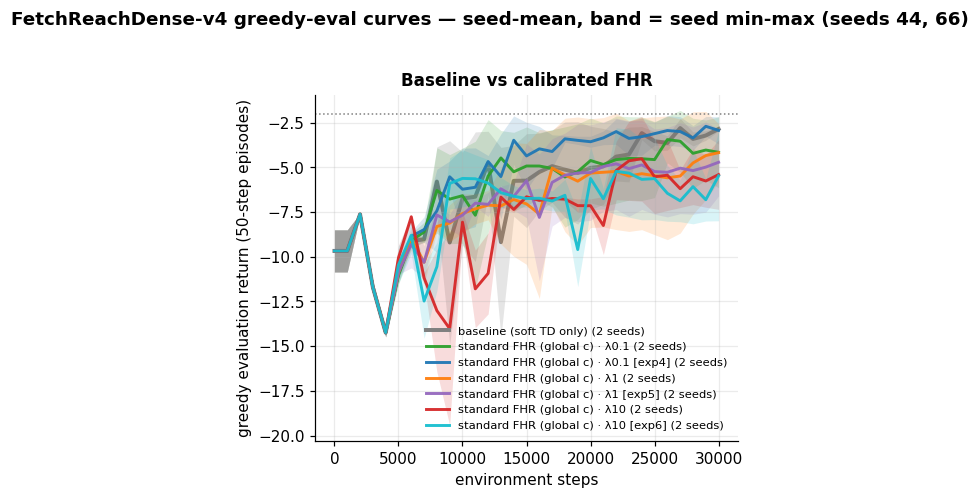

In [8]:
GROUP_DEFS = [("Baseline vs calibrated FHR", ("baseline", "probe", "global")),
              ("State-conditioned c(s,a)", ("ar",)),
              ("Prioritized replay", ("per",))]
GROUPS = [(t, labels_of(*kinds)) for t, kinds in GROUP_DEFS]
GROUPS = [(t, ls) for t, ls in GROUPS if ls]

def seed_band(ax, label, colr=None, lw=1.9, alpha=0.95, band_alpha=0.16,
              legend=True, zorder=2, **kw):
    cs = curves(ARMS[label][0], **kw)
    if not cs:
        return
    n = min(len(y) for _, _, y in cs)
    x, Y = cs[0][1][:n], np.stack([y[:n] for _, _, y in cs])
    colr = colr or ARMS[label][1]
    if len(cs) > 1:
        ax.fill_between(x, Y.min(0), Y.max(0), color=colr, alpha=band_alpha,
                        lw=0, zorder=zorder - 1)
    ax.plot(x, Y.mean(0), lw=lw, color=colr, alpha=alpha, zorder=zorder,
            label=f"{label} ({len(cs)} seeds)" if legend else None)

fig, axes = plt.subplots(1, len(GROUPS), figsize=(4.9 * len(GROUPS), 4.4),
                         sharey=True, squeeze=False)
for ax, (title, labels) in zip(axes.ravel(), GROUPS):
    if BASE:
        seed_band(ax, BASE, "gray", lw=2.6, alpha=1.0, band_alpha=0.20,
                  legend=BASE in labels, zorder=1)
    for label in labels:
        if label == BASE:
            continue
        seed_band(ax, label)
    ax.axhline(-2, color="gray", ls=":", lw=1)
    ax.set(title=title, xlabel="environment steps")
    ax.legend(fontsize=7.5, loc="lower right")
axes[0, 0].set_ylabel("greedy evaluation return (50-step episodes)")
fig.suptitle(f"{CFG['environment']['name']} greedy-eval curves — seed-mean, "
             f"band = seed min-max (seeds {', '.join(SEEDS)})",
             fontweight="bold", y=1.02)
plt.tight_layout()

## 3 · Final performance

baseline (soft TD only)                         -2.8   [-3.0, -2.7]
standard FHR (global c) · λ0.1                  -4.2   [-6.1, -2.2]
standard FHR (global c) · λ0.1 [exp4]           -2.9   [-3.7, -2.2]
standard FHR (global c) · λ1                    -4.2   [-5.8, -2.6]
standard FHR (global c) · λ1 [exp5]             -4.7   [-6.6, -2.8]
standard FHR (global c) · λ10                   -5.4   [-7.3, -3.5]
standard FHR (global c) · λ10 [exp6]            -5.5   [-8.0, -3.0]


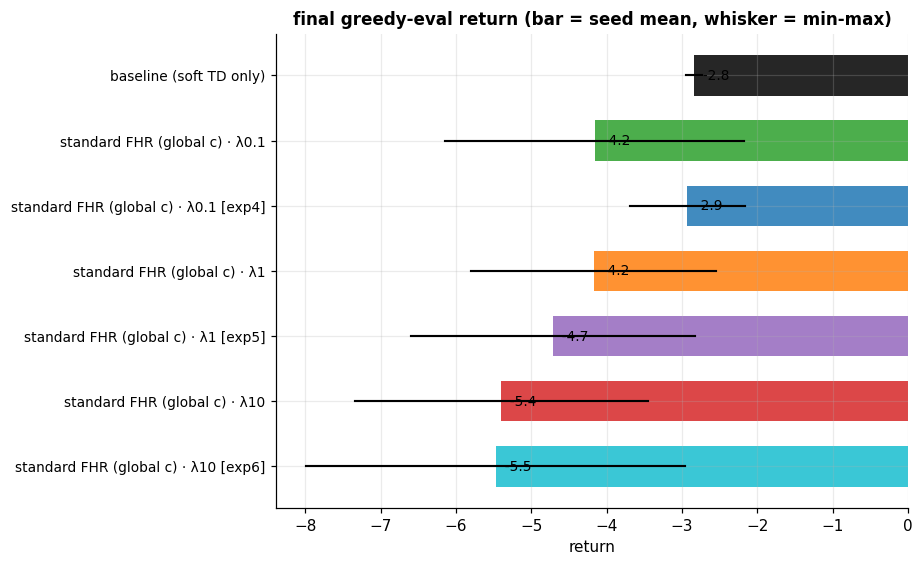

In [9]:
# Final greedy-eval performance per arm (last eval.csv row, mean over seeds)
rows = []
for label in ARMS:
    cs = curves(ARMS[label][0])
    if cs:
        finals = [y[-1] for _, _, y in cs]
        rows.append((label, np.mean(finals), np.min(finals), np.max(finals),
                     ARMS[label][1]))
fig, ax = plt.subplots(figsize=(8.5, 0.55 * len(rows) + 1.4))
ypos = np.arange(len(rows))[::-1]
for y, (label, mean, lo, hi, colr) in zip(ypos, rows):
    ax.barh(y, mean, color=colr, alpha=0.85, height=0.62)
    ax.plot([lo, hi], [y, y], color="black", lw=1.4)
    ax.text(mean, y, f"  {mean:.1f}", va="center", fontsize=9)
ax.set_yticks(ypos, [r[0] for r in rows], fontsize=9)
ax.set(title="final greedy-eval return (bar = seed mean, whisker = min-max)",
       xlabel="return")
plt.tight_layout()
for label, mean, lo, hi, _ in rows:
    print(f"{label:42s} {mean:9.1f}   [{lo:.1f}, {hi:.1f}]")

## 4 · FHR + SAC internals

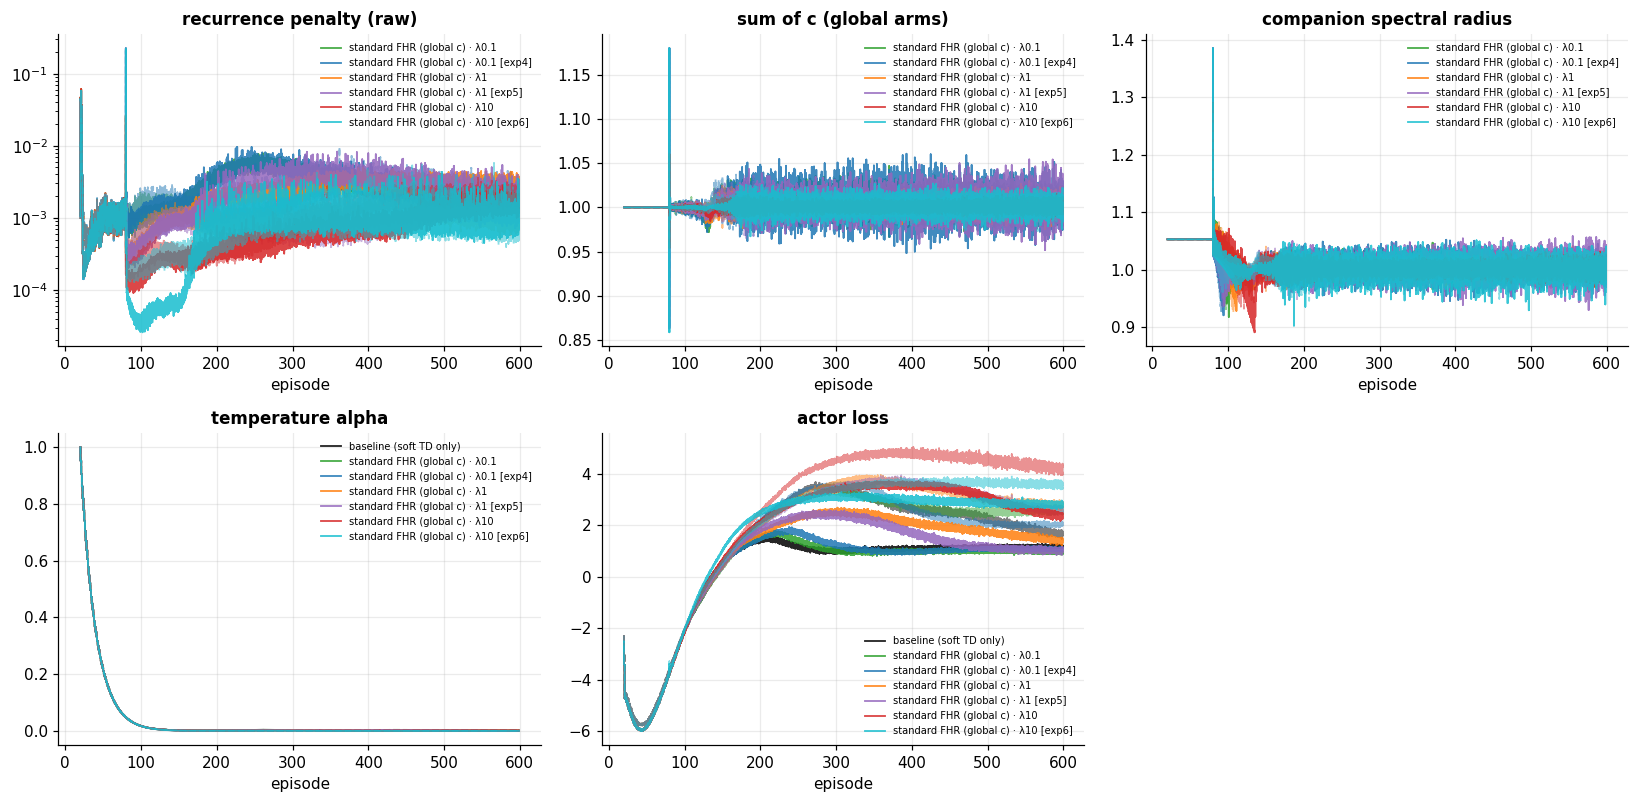

In [10]:
# FHR/SAC internals per gradient-burst row: the recurrence penalty, the
# learned coefficients, the temperature and the actor loss.
panels = [("penalty_raw", "recurrence penalty (raw)", labels_of("global", "ar", "per")),
          ("sum_c", "sum of c (global arms)", GLOBALS_ + PER_ARMS),
          ("c_spread", "c(s,a) spread (ccond arms)", VARIANTS),
          ("companion_radius", "companion spectral radius", GLOBALS_ + PER_ARMS),
          ("ent_coef", "temperature alpha", list(ARMS)),
          ("actor_loss", "actor loss", list(ARMS))]
panels = [(c, t, ls) for c, t, ls in panels if ls]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.4))
for ax, (col, title, labels) in zip(axes.ravel(), panels):
    for label in labels:
        for s, x, y in diag(ARMS[label][0], col):
            m = np.isfinite(y)
            if m.any():
                ax.plot(x[m], y[m], lw=1.2, color=ARMS[label][1],
                        alpha=0.85 if s == SEEDS[0] else 0.5,
                        ls="-" if s == SEEDS[0] else "--",
                        label=label if s == SEEDS[0] else None)
    ax.set(title=title, xlabel="episode")
    if col in ("penalty_raw",):
        ax.set_yscale("log")
    ax.legend(fontsize=6.5)
for ax in axes.ravel()[len(panels):]:
    ax.axis("off")
plt.tight_layout()

## 5 · Rollout Hankel rank — critic trace and the policy itself

AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


arm                                            rank(Q)  ranks(pi dims)
baseline (soft TD only)                              1  [3, 4, 5, 3]
standard FHR (global c) · λ0.1                       1  [3, 4, 5, 4]
standard FHR (global c) · λ0.1 [exp4]                1  [4, 4, 4, 3]
standard FHR (global c) · λ1                         2  [6, 5, 3, 5]
standard FHR (global c) · λ1 [exp5]                  1  [4, 2, 6, 2]
standard FHR (global c) · λ10                        1  [8, 8, 9, 3]
standard FHR (global c) · λ10 [exp6]                 1  [9, 9, 7, 7]


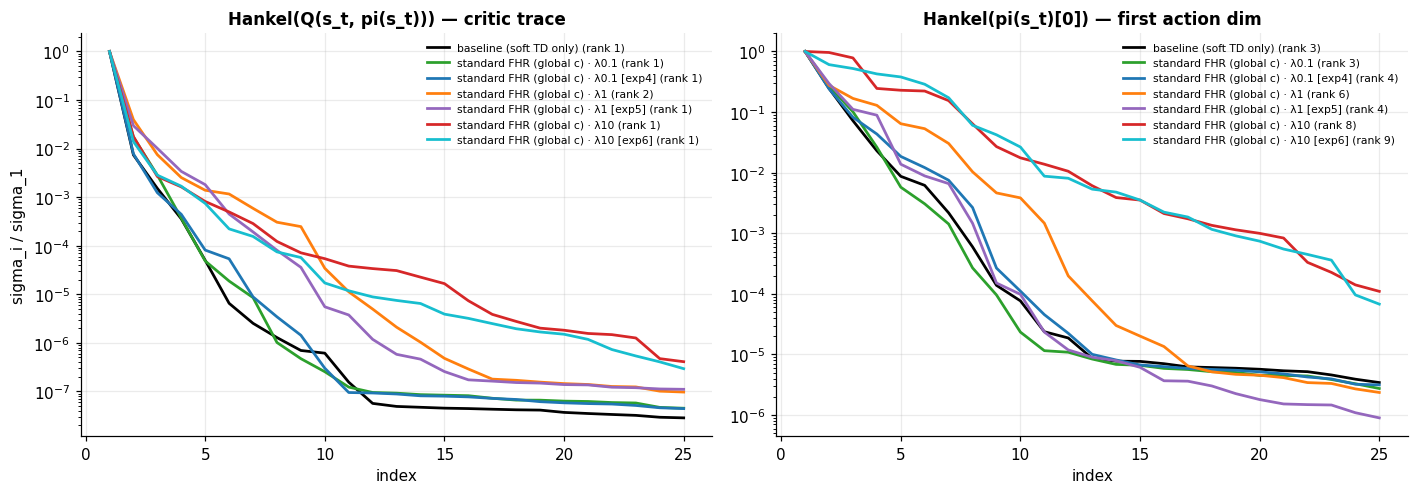

In [11]:
# Rollout Hankel spectra per arm: the critic trace Q(s_t, pi(s_t)) and the
# policy trajectory's action dims. Fetch episodes are 50 steps; 3 rollouts
# stack to (78, 25) Hankels.
from analysis.low_rank.continuous_rollout import hankel_rollout_continuous
from analysis.low_rank.rank import energy_rank

SHOW = [l for l in ([BASE] + labels_of("probe")[:1] + GLOBALS_ + VARIANTS
                    + PER_ARMS) if l]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
table = []
for label in SHOW:
    arm = ARMS[label][0]
    dirs = run_dirs(arm)
    if not dirs:
        continue
    _, adapter = runner.load_run_model(dirs[0][1], device="cpu")
    env = runner._make_env(CFG)
    mats = hankel_rollout_continuous(adapter, env, n_rollouts=3, base_seed=52)
    env.close()
    h_q, h_acts = mats[0], mats[1:]
    ranks = []
    sv = np.linalg.svd(h_q, compute_uv=False); sv = sv / sv[0]
    rq = energy_rank(sv, 0.999); ranks.append(rq)
    axes[0].semilogy(np.arange(1, min(len(sv), 25) + 1), sv[:25], lw=1.8,
                     color=ARMS[label][1], label=f"{label} (rank {rq})")
    pi_ranks = []
    for j, h_a in enumerate(h_acts):
        sva = np.linalg.svd(h_a, compute_uv=False); sva = sva / sva[0]
        ra = energy_rank(sva, 0.999)
        pi_ranks.append(ra)
        if j == 0:
            axes[1].semilogy(np.arange(1, min(len(sva), 25) + 1), sva[:25],
                             lw=1.8, color=ARMS[label][1],
                             label=f"{label} (rank {ra})")
    table.append((label, rq, pi_ranks))
axes[0].set(title="Hankel(Q(s_t, pi(s_t))) — critic trace", xlabel="index",
            ylabel="sigma_i / sigma_1")
axes[1].set(title="Hankel(pi(s_t)[0]) — first action dim", xlabel="index")
for ax in axes:
    ax.legend(fontsize=7)
plt.tight_layout()
print(f"{'arm':46s} rank(Q)  ranks(pi dims)")
for label, rq, pr in table:
    print(f"{label:46s} {rq:7d}  {pr}")

## 6 · GB10 cost

In [12]:
# GB10 wall-clock per run, from the launcher logs (cached/logs/sb3_sac_*.log
# mtimes bracket each run; the parent prints per-run minutes into its own
# stdout, so here we use the run dirs' filesystem timestamps as a proxy:
# checkpoint mtime - config mtime ~ training duration).
import os
rows = []
for label in ARMS:
    for s, d in run_dirs(ARMS[label][0]):
        t0 = os.path.getmtime(d / "config.yaml")
        t1 = os.path.getmtime(d / "checkpoints" / "final.pt")
        rows.append((label, s, (t1 - t0) / 60))
for label, s, mins in rows:
    print(f"{label:46s} seed {s}: {mins:6.1f} min")
base = [m for l, _, m in rows if l == BASE]
fhr = [m for l, _, m in rows if l != BASE and "probe" not in l]
if base and fhr:
    print(f"\nbaseline mean {np.mean(base):.1f} min; "
          f"FHR-arm mean {np.mean(fhr):.1f} min "
          f"(overhead x{np.mean(fhr)/np.mean(base):.2f})")

baseline (soft TD only)                        seed 44:   10.0 min
baseline (soft TD only)                        seed 66:   10.1 min
standard FHR (global c) · λ0.1                 seed 44:   12.3 min
standard FHR (global c) · λ0.1                 seed 66:   12.4 min
standard FHR (global c) · λ0.1 [exp4]          seed 44:   12.2 min
standard FHR (global c) · λ0.1 [exp4]          seed 66:   12.3 min
standard FHR (global c) · λ1                   seed 44:   12.4 min
standard FHR (global c) · λ1                   seed 66:   12.3 min
standard FHR (global c) · λ1 [exp5]            seed 44:   12.2 min
standard FHR (global c) · λ1 [exp5]            seed 66:   12.2 min
standard FHR (global c) · λ10                  seed 44:   12.4 min
standard FHR (global c) · λ10                  seed 66:   12.4 min
standard FHR (global c) · λ10 [exp6]           seed 44:   10.4 min
standard FHR (global c) · λ10 [exp6]           seed 66:   10.4 min

baseline mean 10.0 min; FHR-arm mean 12.0 min (overhead x1.19

## 7 · Final policy rollouts — videos

How the final rollout is made: `record_final_videos` reloads each run's
**final checkpoint** (`checkpoints/final.pt` — the policy exactly as it stood
at the end of the training budget; the SB3 zip is self-describing, FHR
coefficients included), rebuilds the same `_make_env` wrapper stack the run
trained and eval'd on (FlattenObservation over the goal-conditioned Dict obs)
with `render_mode="rgb_array"`, and rolls **one greedy episode** — the
deterministic SAC actor (tanh-squashed mean, no sampling), i.e. the same
policy the `eval.csv` curves score — through gymnasium's `RecordVideo`, which
writes `<run_dir>/videos/epfinal-episode-0.mp4`. The episode resets with the
run's own seed, so each video is one representative 50-step reach per
(arm, seed), not the 10-episode eval average. Only arms with completed
manifest runs appear; re-run after a sweep finishes to add the rest.

In [13]:
import os
os.environ.setdefault("MUJOCO_GL", "egl")   # headless MuJoCo rendering
from IPython.display import Video, display
from run_sb3_seeds import record_final_videos

for label in ([BASE] if BASE else []) + GLOBALS_ + VARIANTS + PER_ARMS:
    arm = ARMS[label][0]
    try:
        vids = record_final_videos(arm, config=CONFIG)
    except RuntimeError as e:   # arm not finished in this config's manifest yet
        print(f"{label} ({arm}): skipped — {e}")
        continue
    for seed, path in vids:
        print(f"{label} ({arm}) — seed {seed}: {path}")
        display(Video(str(path), embed=True, width=420))

/home/souparna/Low-Rank-RL-TL/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/souparna/Low-Rank-RL-TL/experiments/stable_baselines_3/fetch_reach/cached/runs/sb3_fetch_reach_sac_16_16_baseline_seed44_20260827-152017/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/home/souparna/Low-Rank-RL-TL/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/souparna/Low-Rank-RL-TL/experiments/stable_baselines_3/fetch_reach/cached/runs/sb3_fetch_reach_sac_16_16_baseline_seed66_20260827-152018/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


baseline (soft TD only) (baseline) — seed 44: /home/souparna/Low-Rank-RL-TL/experiments/stable_baselines_3/fetch_reach/cached/runs/sb3_fetch_reach_sac_16_16_baseline_seed44_20260827-152017/videos/epfinal-episode-0.mp4


baseline (soft TD only) (baseline) — seed 66: /home/souparna/Low-Rank-RL-TL/experiments/stable_baselines_3/fetch_reach/cached/runs/sb3_fetch_reach_sac_16_16_baseline_seed66_20260827-152018/videos/epfinal-episode-0.mp4


/home/souparna/Low-Rank-RL-TL/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/souparna/Low-Rank-RL-TL/experiments/stable_baselines_3/fetch_reach/cached/runs/sb3_fetch_reach_sac_16_16_exp1_seed44_20260827-152018/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/home/souparna/Low-Rank-RL-TL/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/souparna/Low-Rank-RL-TL/experiments/stable_baselines_3/fetch_reach/cached/runs/sb3_fetch_reach_sac_16_16_exp1_seed66_20260827-152017/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


standard FHR (global c) · λ0.1 (exp1) — seed 44: /home/souparna/Low-Rank-RL-TL/experiments/stable_baselines_3/fetch_reach/cached/runs/sb3_fetch_reach_sac_16_16_exp1_seed44_20260827-152018/videos/epfinal-episode-0.mp4


...

standard FHR (global c) · λ1 [exp5] (exp5) — seed 66: /home/souparna/Low-Rank-RL-TL/experiments/stable_baselines_3/fetch_reach/cached/runs/sb3_fetch_reach_sac_16_16_exp5_seed66_20260827-154514/videos/epfinal-episode-0.mp4


standard FHR (global c) · λ10 (exp3) — seed 44: /home/souparna/Low-Rank-RL-TL/experiments/stable_baselines_3/fetch_reach/cached/runs/sb3_fetch_reach_sac_16_16_exp3_seed44_20260827-153239/videos/epfinal-episode-0.mp4


standard FHR (global c) · λ10 (exp3) — seed 66: /home/souparna/Low-Rank-RL-TL/experiments/stable_baselines_3/fetch_reach/cached/runs/sb3_fetch_reach_sac_16_16_exp3_seed66_20260827-153247/videos/epfinal-episode-0.mp4


standard FHR (global c) · λ10 [exp6] (exp6) — seed 44: /home/souparna/Low-Rank-RL-TL/experiments/stable_baselines_3/fetch_reach/cached/runs/sb3_fetch_reach_sac_16_16_exp6_seed44_20260827-155505/videos/epfinal-episode-0.mp4


standard FHR (global c) · λ10 [exp6] (exp6) — seed 66: /home/souparna/Low-Rank-RL-TL/experiments/stable_baselines_3/fetch_reach/cached/runs/sb3_fetch_reach_sac_16_16_exp6_seed66_20260827-155512/videos/epfinal-episode-0.mp4


## 8 · Findings

*(fill in after the sweep completes)*

## Penalised-window Hankel rank (in-training probe)

Rank measured **where the penalty is applied** — on sampled replay windows
(anchor + `window_rank_lags` same-episode predecessors, online critic(s),
buffer actions) rather than on greedy on-policy rollouts. The probe runs for
every arm **including the λ=0 baseline**, which samples and measures the same
windows, so its curve is the control: if FHR operates as a rank constraint,
its arms should push the window rank / the penalty-block tail ratio *below*
the baseline on exactly these windows. Only instrumented runs
(`agent.window_rank_every > 0`, e.g. the `*_wrank` config family) carry
`window_hankel.csv`; older runs are skipped. Raw window matrices are in each
run's `window_matrices/` for offline re-analysis.


In [ ]:
# Penalised-window Hankel rank: scans every manifest under cached/ for runs
# carrying window_hankel.csv (the in-training probe's output) and, per
# family, plots rank + penalty-block tail ratio vs env steps for every arm.
import pathlib, sys
_repo = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "analysis").is_dir())
if str(_repo / "src") not in sys.path:
    sys.path.insert(0, str(_repo / "src"))
import numpy as np
import matplotlib.pyplot as plt
from analysis.low_rank.window_rank import (arm_tick_metrics,
                                           discover_probe_runs,
                                           final_quarter_summary)

_families = discover_probe_runs("cached")
if not _families:
    print("no instrumented runs under cached/ — launch a family with "
          "agent.window_rank_every > 0 (see the *_wrank config) first")
_palette = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
            "tab:cyan", "peru", "orchid", "tab:olive", "crimson"]
for _mname, _arms in _families.items():
    _fig, (_ax_r, _ax_p) = plt.subplots(1, 2, figsize=(13, 4.4))
    print(f"===== {_mname} =====")
    print(f"{'arm':24s} {'rank@99.9%':>10} {'rank@99%':>9} {'s2/s1':>8} "
          f"{'pen tail':>9}   (final-quarter means, seeds x critics)")
    _ci = 0
    for _arm, _dirs in _arms.items():
        _mets = arm_tick_metrics(_dirs)
        if not _mets:
            continue
        if _arm == "baseline":
            _col = "black"
        else:
            _col = _palette[_ci % len(_palette)]
            _ci += 1
        for _k, (_seed, _m) in enumerate(_mets):
            _lab = _arm if _k == 0 else None
            _lw = 2.0 if _arm == "baseline" else 1.2
            _ax_r.plot(_m["env_steps"], _m["rank999"], color=_col,
                       alpha=0.85, lw=_lw, label=_lab)
            _ax_p.semilogy(_m["env_steps"], _m["pen_tail_ratio"], color=_col,
                           alpha=0.85, lw=_lw, label=_lab)
        _s = final_quarter_summary(_mets)
        if _s:
            print(f"{_arm:24s} {_s['rank999']:10.1f} {_s['rank99']:9.1f} "
                  f"{_s['s2_s1']:8.4f} {_s['pen_tail_ratio']:9.4f}")
    _ax_r.set(title="energy rank @ 99.9% — penalised replay windows",
              xlabel="env steps", ylabel="rank")
    _ax_p.set(title="penalty-block tail  sigma_{r+1} / sigma_1",
              xlabel="env steps")
    for _ax in (_ax_r, _ax_p):
        _ax.legend(fontsize=7.5)
    _fig.suptitle(_mname, fontsize=10)
    plt.tight_layout()
    plt.show()
